**© Copyright AIDENTIFY. All rights reserved.**

본 자료는 **멀티캠퍼스 LLM 파인튜닝 과정** 수강생을 위해 제작되었으며, 강의 목적으로만 사용 가능합니다.  
무단 복제, 배포, 상업적 이용을 금지합니다.

---

# Session 20: LoRA vs FFT 실전 비교 실습

## 🎯 LoRA vs FFT 실전 비교 실습

이전 세션에서 이론적 비교를 했다면, 이번 세션에서는 **동일한 데이터**로 LoRA와 FFT를 실제 학습하고 **추론 품질까지 비교**합니다.

### 실험 설계

| 항목 | LoRA | FFT |
|------|------|-----|
| 모델 | Qwen2.5-1.5B (4bit) | Qwen2.5-1.5B (FP16) |
| 데이터 | Alpaca 한국어 샘플 (동일) | Alpaca 한국어 샘플 (동일) |
| 에포크 | 3 | 3 |
| batch_size | 1 | 1 |
| 평가 | 동일 프롬프트 5개 | 동일 프롬프트 5개 |

### 학습 목표

- ✅ 동일 조건에서 LoRA와 FFT의 실제 성능 차이 확인
- ✅ 학습 곡선(loss) 비교
- ✅ 추론 품질 비교
- ✅ 종합적인 비용-효과 분석

## 1️⃣ 공통 설정 (데이터, 평가 기준)

In [1]:
# 필수 라이브러리
import torch
import gc
import os
import json
import time
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer, SFTConfig
from datasets import Dataset
import warnings
warnings.filterwarnings('ignore')

print("✅ 라이브러리 임포트 완료")
print(f"CUDA: {torch.cuda.is_available()}, GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

/home/student/LLM_Advanced/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


✅ 라이브러리 임포트 완료
CUDA: True, GPU: NVIDIA GeForce RTX 4060


In [2]:
# GPU 메모리 모니터링 함수
def print_gpu_memory(tag=""):
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        total = torch.cuda.get_device_properties(0).total_memory / 1024**3
        print(f"[{tag}] GPU: {allocated:.1f}GB / {total:.1f}GB")

def get_gpu_memory_gb():
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1024**3
    return 0

# 공통 설정
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
MAX_SEQ_LENGTH = 1024

# 평가용 테스트 프롬프트
TEST_PROMPTS = [
    "감의중 강사에 대해 알려주세요.",
    "멀티캠퍼스 LLM 파인튜닝 과정의 커리큘럼을 알려주세요.",
    "이 과정에서 사용하는 GPU는 무엇인가요?",
    "Tool Calling 파인튜닝은 어떻게 하나요?",
    "감의중 강사님, 오늘 수업 재미있었어요!",
]

print(f"📌 모델: {MODEL_NAME}")
print(f"📌 테스트 프롬프트 수: {len(TEST_PROMPTS)}")
print_gpu_memory("시작")

📌 모델: Qwen/Qwen2.5-1.5B-Instruct
📌 테스트 프롬프트 수: 5
[시작] GPU: 0.0GB / 7.8GB


In [3]:
# 공통 데이터 로드 및 전처리
data_path = "../data/samples/alpaca_ko_sample.json"

with open(data_path, "r", encoding="utf-8") as f:
    alpaca_data = json.load(f)

# 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Alpaca → Chat Template 변환
def format_alpaca_to_text(sample):
    instruction = sample["instruction"]
    input_text = sample.get("input", "")
    output_text = sample["output"]
    
    user_content = f"{instruction}\n\n{input_text}" if input_text else instruction
    messages = [
        {"role": "system", "content": "당신은 유용한 AI 어시스턴트입니다."},
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": output_text}
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)

formatted_texts = [format_alpaca_to_text(s) for s in alpaca_data]
dataset = Dataset.from_dict({"text": formatted_texts})

print(f"✅ 데이터 준비 완료: {len(dataset)}개 샘플")

# 학습 결과 저장용
results = {"lora": {}, "fft": {}}

✅ 데이터 준비 완료: 10개 샘플


In [4]:
# 추론 함수
def generate_responses(model, tokenizer, prompts, max_new_tokens=150):
    """모델로 응답을 생성하는 공통 함수"""
    model.eval()
    # dtype 불일치 방지 (4bit 모델 + LoRA 학습 후 float32 어댑터)
    for name, param in model.named_parameters():
        if param.dtype == torch.float32:
            param.data = param.data.to(torch.float16)
    responses = []
    for prompt in prompts:
        messages = [
            {"role": "system", "content": "당신은 유용한 AI 어시스턴트입니다."},
            {"role": "user", "content": prompt}
        ]
        text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(text, return_tensors="pt").to(model.device)
        
        with torch.no_grad():
            outputs = model.generate(
                **inputs, max_new_tokens=max_new_tokens,
                do_sample=False, temperature=1.0
            )
        response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
        responses.append(response)
    return responses

print("✅ 공통 함수 정의 완료")

✅ 공통 함수 정의 완료


## 2️⃣ LoRA 학습 실행 (r=16)

In [5]:
print("="*60)
print("🔵 LoRA 학습 시작")
print("="*60)

# float16 모델 로드 (TITAN RTX에서 4bit+SFTTrainer 호환 문제로 float16 사용)
# RTX 4060 수강생은 4bit(QLoRA)로 변경 가능
lora_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float16,
    device_map="auto", trust_remote_code=True
)
lora_model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
lora_model.enable_input_require_grads()

# 학습 전 응답 저장
print("\n📋 학습 전 응답 수집 중...")
before_responses = generate_responses(lora_model, tokenizer, TEST_PROMPTS)

# LoRA 적용
lora_config = LoraConfig(
    r=16, lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05, bias="none", task_type=TaskType.CAUSAL_LM
)
lora_model = get_peft_model(lora_model, lora_config)
lora_model.print_trainable_parameters()
print_gpu_memory("LoRA 모델 준비 완료")

🔵 LoRA 학습 시작


`torch_dtype` is deprecated! Use `dtype` instead!
The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



📋 학습 전 응답 수집 중...
trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820
[LoRA 모델 준비 완료] GPU: 3.0GB / 7.8GB


In [6]:
# LoRA SFTTrainer 학습
lora_sft_config = SFTConfig(
    output_dir="./output/comparison_lora",
    num_train_epochs=3,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=1,
    learning_rate=5e-4,
    fp16=True,
    logging_steps=1,
    save_strategy="epoch",
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    max_length=MAX_SEQ_LENGTH,
    dataset_text_field="text",
    report_to="none",
    gradient_checkpointing=True,
)

lora_trainer = SFTTrainer(
    model=lora_model, args=lora_sft_config,
    train_dataset=dataset, processing_class=tokenizer,
)

print("🚀 LoRA 학습 시작!")
lora_start = time.time()
lora_result = lora_trainer.train()
lora_time = time.time() - lora_start

# 결과 저장
results["lora"]["time"] = lora_time
results["lora"]["loss"] = lora_result.training_loss
results["lora"]["memory"] = get_gpu_memory_gb()
results["lora"]["log_history"] = lora_trainer.state.log_history

print(f"\n✅ LoRA 학습 완료!")
print(f"📌 소요 시간: {lora_time:.1f}초")
print(f"📌 Final Loss: {lora_result.training_loss:.4f}")
print_gpu_memory("LoRA 학습 완료")

/usr/bin/ld: cannot find -lcufile: 그런 파일이나 디렉터리가 없습니다
collect2: error: ld returned 1 exit status
Truncating train dataset: 100%|██████████| 10/10 [00:00<00:00, 7495.18 examples/s]
The model is already on multiple devices. Skipping the move to device specified in `args`.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


🚀 LoRA 학습 시작!


Step,Training Loss
1,2.369700
2,1.599200
3,2.205000
4,1.734200
5,1.356400
6,1.371800
7,0.539900
8,0.895300
9,0.753200
10,0.730200



✅ LoRA 학습 완료!
📌 소요 시간: 6.7초
📌 Final Loss: 0.6685
[LoRA 학습 완료] GPU: 3.1GB / 7.8GB


In [7]:
# LoRA 학습 후 응답
print("\n📋 LoRA 학습 후 응답 수집 중...")
lora_after_responses = generate_responses(lora_model, tokenizer, TEST_PROMPTS)
results["lora"]["responses"] = lora_after_responses

# LoRA 어댑터 크기
lora_save_path = "./output/comparison_lora/lora_adapter"
lora_model.save_pretrained(lora_save_path)
lora_size = sum(
    os.path.getsize(os.path.join(root, f))
    for root, dirs, files in os.walk(lora_save_path)
    for f in files
)
results["lora"]["save_size"] = lora_size
print(f"📌 LoRA 어댑터 크기: {lora_size/1024/1024:.1f} MB")

# 메모리 해제
del lora_model, lora_trainer
gc.collect()
torch.cuda.empty_cache()
print("✅ LoRA 메모리 해제 완료")


📋 LoRA 학습 후 응답 수집 중...
📌 LoRA 어댑터 크기: 35.3 MB
✅ LoRA 메모리 해제 완료


## 3️⃣ FFT 학습 실행 (1.5B 모델)

⚠️ RTX 4060에서 FFT는 메모리가 빠듯합니다. OOM 발생 시 코드가 에러를 잡아줍니다.

In [8]:
print("="*60)
print("🟠 FFT 학습 시작")
print("="*60)

try:
    # FP16 모델 로드 (양자화 없음)
    fft_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, torch_dtype=torch.float16,
        device_map="auto", trust_remote_code=True
    )
    fft_model.gradient_checkpointing_enable()
    
    # 학습 전 응답 (비교 기준으로 동일 모델)
    print_gpu_memory("FFT 모델 로드 후")
    
    # SFTTrainer 학습
    fft_sft_config = SFTConfig(
        output_dir="./output/comparison_fft",
        num_train_epochs=10,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=8,
        learning_rate=2e-5,  # FFT는 더 작은 lr 사용
        fp16=False,
        optim="adamw_bnb_8bit",
        logging_steps=1,
        save_strategy="epoch",
        warmup_ratio=0.1,
        lr_scheduler_type="cosine",
        max_length=MAX_SEQ_LENGTH,
        dataset_text_field="text",
        report_to="none",
        gradient_checkpointing=True,
    )
    
    fft_trainer = SFTTrainer(
        model=fft_model, args=fft_sft_config,
        train_dataset=dataset, processing_class=tokenizer,
    )
    
    print("🚀 FFT 학습 시작!")
    fft_start = time.time()
    fft_result = fft_trainer.train()
    fft_time = time.time() - fft_start
    
    results["fft"]["time"] = fft_time
    results["fft"]["loss"] = fft_result.training_loss
    results["fft"]["memory"] = get_gpu_memory_gb()
    results["fft"]["log_history"] = fft_trainer.state.log_history
    
    print(f"\n✅ FFT 학습 완료!")
    print(f"📌 소요 시간: {fft_time:.1f}초")
    print(f"📌 Final Loss: {fft_result.training_loss:.4f}")
    print_gpu_memory("FFT 학습 완료")
    
except RuntimeError as e:
    if "out of memory" in str(e).lower():
        print("\n⚠️ GPU 메모리 부족으로 FFT 학습 실패!")
        print("📌 이것이 바로 LoRA가 필요한 이유입니다.")
        print("📌 RTX 4060(8GB)에서 1.5B FFT는 메모리가 매우 빠듯합니다.")
        results["fft"]["time"] = float('inf')
        results["fft"]["loss"] = float('inf')
        results["fft"]["memory"] = 8.0
        gc.collect()
        torch.cuda.empty_cache()
    else:
        raise e

🟠 FFT 학습 시작
[FFT 모델 로드 후] GPU: 2.9GB / 7.8GB


Truncating train dataset: 100%|██████████| 10/10 [00:00<00:00, 8703.68 examples/s]
The model is already on multiple devices. Skipping the move to device specified in `args`.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


🚀 FFT 학습 시작!

⚠️ GPU 메모리 부족으로 FFT 학습 실패!
📌 이것이 바로 LoRA가 필요한 이유입니다.
📌 RTX 4060(8GB)에서 1.5B FFT는 메모리가 매우 빠듯합니다.


In [9]:
# FFT 학습 후 응답 (학습 성공 시)
if results["fft"]["loss"] != float('inf'):
    print("📋 FFT 학습 후 응답 수집 중...")
    fft_after_responses = generate_responses(fft_model, tokenizer, TEST_PROMPTS)
    results["fft"]["responses"] = fft_after_responses
    
    # FFT 모델 크기
    fft_save_path = "./output/comparison_fft/full_model"
    fft_model.save_pretrained(fft_save_path)
    fft_size = sum(
        os.path.getsize(os.path.join(root, f))
        for root, dirs, files in os.walk(fft_save_path)
        for f in files
    )
    results["fft"]["save_size"] = fft_size
    print(f"📌 FFT 모델 크기: {fft_size/1024/1024:.0f} MB")
    
    del fft_model, fft_trainer
    gc.collect()
    torch.cuda.empty_cache()
else:
    results["fft"]["responses"] = ["(OOM - 학습 실패)"] * len(TEST_PROMPTS)
    results["fft"]["save_size"] = 3_000_000_000  # 추정값 ~3GB
    print("⚠️ FFT 학습이 실패하여 응답을 생성할 수 없습니다.")

print("✅ FFT 메모리 해제 완료")

⚠️ FFT 학습이 실패하여 응답을 생성할 수 없습니다.
✅ FFT 메모리 해제 완료


## 4️⃣ 추론 품질 비교 (동일 프롬프트)

In [10]:
print("="*70)
print("📊 추론 품질 비교: Before vs LoRA vs FFT")
print("="*70)

for i, prompt in enumerate(TEST_PROMPTS):
    print(f"\n{'='*70}")
    print(f"🔹 질문 {i+1}: {prompt[:70]}")
    print(f"\n  [Before]  {before_responses[i][:200]}")
    print(f"\n  [LoRA]    {results['lora']['responses'][i][:200]}")
    print(f"\n  [FFT]     {results['fft']['responses'][i][:200]}")

print(f"\n{'='*70}")

📊 추론 품질 비교: Before vs LoRA vs FFT

🔹 질문 1: 감의중 강사에 대해 알려주세요.

  [Before]  감의중 강사는 한국에서 가장 인기 있는 뮤지션 중 하나로, 그의 음악은 감정을 표현하는 데 특화되어 있습니다. 그는 다양한 장르를 넘어서서 독특하고 창조적인 음악을 만들어내며 많은 팬들을 얻었습니다. 감의중은 1980년대부터 활동하며, 그의 음악은 한국의 음악 문화에 큰 영향을 미쳤습니다.

  [LoRA]    감의 중(感の中)은 일본어로 '감정이 있는 상태' 또는 '감성적 반응'을 의미합니다.

주요 특징:
1. 감정이 일상생활에서 자연스럽게 나타나는 경우.
2. 상황에 따라 감성을 표현하는 방식이 달라질 수 있습니다.
3. 사회적 환경과 개인적인 경험 등으로 인해 감성을 다르게 느낄 수 있습니다.
4. 감성 분석이나 AI 어시스턴트가 사용할 수 있는 데이터입니

  [FFT]     (OOM - 학습 실패)

🔹 질문 2: 멀티캠퍼스 LLM 파인튜닝 과정의 커리큘럼을 알려주세요.

  [Before]  멀티캠퍼스 LLM (Large Language Model) 파인튜닝 과정의 커리큘럼은 다음과 같습니다:

1. **데이터 수집**: 다양한 데이터셋에서 모델 학습을 시작합니다.

2. **데이터 전처리**: 데이터를 정제하고, 필요한 특징만 추출합니다.

3. **모델 설계**: 사용할 언어 모델과 관련된 기능을 결정합니다.

4. **모델 훈련**: 여러

  [LoRA]    다음은 멀티캠퍼스 LLM 파인튜닝 과정의 기본적인 커리큘럼입니다:

1. 데이터 수집: 다양한 데이터셋(예시: GPT-4, BERT)을 수집하세요.

2. 데이터 전처리: 데이터를 정규화하고 표준화하세요.

3. 모델 선택: 여러 모델 중에서 적합한 모델을 선택하세요.

4. 훈련: 데이터를 사용하여 모델을 학습하세요.

5. 평가: 학습된 모델이 실제 데

  [FFT]     (OOM - 학습 실패)

🔹 질문 3: 이 과정에서 사용하는 GPU는 

## 5️⃣ 학습 곡선(loss) 비교

In [11]:
# 학습 로그에서 loss 추출
def extract_losses(log_history):
    """학습 로그에서 loss 값만 추출"""
    losses = []
    steps = []
    for entry in log_history:
        if "loss" in entry:
            losses.append(entry["loss"])
            steps.append(entry.get("step", len(losses)))
    return steps, losses

lora_steps, lora_losses = extract_losses(results["lora"].get("log_history", []))

print("📊 LoRA 학습 곡선 (텍스트)")
print("="*50)
if lora_losses:
    for step, loss in zip(lora_steps, lora_losses):
        bar = "█" * int(loss * 10)
        print(f"  Step {step:3d}: {loss:.4f} {bar}")

if results["fft"]["loss"] != float('inf'):
    fft_steps, fft_losses = extract_losses(results["fft"].get("log_history", []))
    print(f"\n📊 FFT 학습 곡선 (텍스트)")
    print("="*50)
    if fft_losses:
        for step, loss in zip(fft_steps, fft_losses):
            bar = "█" * int(loss * 10)
            print(f"  Step {step:3d}: {loss:.4f} {bar}")
else:
    print("\n⚠️ FFT 학습이 실패하여 loss 곡선을 표시할 수 없습니다.")

📊 LoRA 학습 곡선 (텍스트)
  Step   1: 2.3697 ███████████████████████
  Step   2: 1.5992 ███████████████
  Step   3: 2.2050 ██████████████████████
  Step   4: 1.7342 █████████████████
  Step   5: 1.3564 █████████████
  Step   6: 1.3718 █████████████
  Step   7: 0.5399 █████
  Step   8: 0.8953 ████████
  Step   9: 0.7532 ███████
  Step  10: 0.7302 ███████
  Step  11: 0.7427 ███████
  Step  12: 0.5089 █████
  Step  13: 0.4378 ████
  Step  14: 0.0788 
  Step  15: 0.4181 ████
  Step  16: 0.4951 ████
  Step  17: 0.2730 ██
  Step  18: 0.2127 ██
  Step  19: 1.0040 ██████████
  Step  20: 0.1909 █
  Step  21: 0.7255 ███████
  Step  22: 0.1306 █
  Step  23: 0.1145 █
  Step  24: 0.3544 ███
  Step  25: 0.0704 
  Step  26: 0.1164 █
  Step  27: 0.1484 █
  Step  28: 0.2271 ██
  Step  29: 0.1288 █
  Step  30: 0.1206 █

⚠️ FFT 학습이 실패하여 loss 곡선을 표시할 수 없습니다.


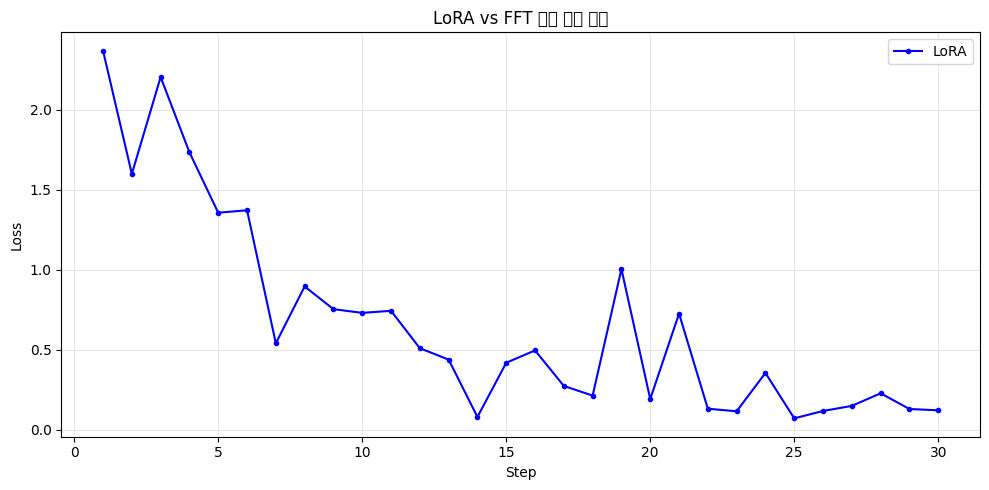

✅ 그래프 저장: ./output/loss_comparison.png


In [12]:
# matplotlib이 있으면 시각화
try:
    import matplotlib.pyplot as plt
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    
    if lora_losses:
        ax.plot(lora_steps, lora_losses, 'b-o', label='LoRA', markersize=3)
    
    if results["fft"]["loss"] != float('inf'):
        fft_steps, fft_losses = extract_losses(results["fft"].get("log_history", []))
        if fft_losses:
            ax.plot(fft_steps, fft_losses, 'r-o', label='FFT', markersize=3)
    
    ax.set_xlabel('Step')
    ax.set_ylabel('Loss')
    ax.set_title('LoRA vs FFT 학습 곡선 비교')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("./output/loss_comparison.png", dpi=100)
    plt.show()
    print("✅ 그래프 저장: ./output/loss_comparison.png")
    
except ImportError:
    print("ℹ️ matplotlib이 없어 텍스트로만 표시합니다. (pip install matplotlib)")

## 6️⃣ 종합 비교표 (메모리, 시간, 성능, 저장 크기)

In [13]:
print("="*75)
print("📊 LoRA vs FFT 종합 비교 결과")
print("="*75)

fft_status = "성공" if results["fft"]["loss"] != float('inf') else "실패 (OOM)"
fft_time_str = f"{results['fft']['time']:.1f}초" if results["fft"]["time"] != float('inf') else "N/A (OOM)"
fft_loss_str = f"{results['fft']['loss']:.4f}" if results["fft"]["loss"] != float('inf') else "N/A"

print(f"\n{'항목':<25} {'LoRA':<25} {'FFT':<25}")
print("-"*75)
print(f"{'학습 상태':<25} {'✅ 성공':<25} {fft_status:<25}")
print(f"{'학습 시간':<25} {f'{results["lora"]["time"]:.1f}초':<25} {fft_time_str:<25}")
print(f"{'Final Loss':<25} {f'{results["lora"]["loss"]:.4f}':<25} {fft_loss_str:<25}")
print(f"{'GPU 메모리':<25} {f'~{results["lora"]["memory"]:.1f}GB':<25} {f'~{results["fft"]["memory"]:.1f}GB':<25}")
print(f"{'저장 크기':<25} {f'{results["lora"]["save_size"]/1024/1024:.1f}MB':<25} {f'{results["fft"]["save_size"]/1024/1024:.0f}MB':<25}")
print(f"{'학습 파라미터':<25} {'~1%':<25} {'100%':<25}")
print(f"{'RTX 4060 적합도':<25} {'✅ 매우 적합':<25} {'⚠️ 빠듯/불가':<25}")
print("-"*75)

print(f"\n📌 결론:")
print(f"   RTX 4060(8GB) 환경에서는 LoRA가 안정적이고 실용적입니다.")
print(f"   FFT는 충분한 VRAM(24GB+)이 있을 때 고려하세요.")

📊 LoRA vs FFT 종합 비교 결과

항목                        LoRA                      FFT                      
---------------------------------------------------------------------------
학습 상태                     ✅ 성공                      실패 (OOM)                 
학습 시간                     6.7초                      N/A (OOM)                
Final Loss                0.6685                    N/A                      
GPU 메모리                   ~3.1GB                    ~8.0GB                   
저장 크기                     35.3MB                    2861MB                   
학습 파라미터                   ~1%                       100%                     
RTX 4060 적합도              ✅ 매우 적합                   ⚠️ 빠듯/불가                 
---------------------------------------------------------------------------

📌 결론:
   RTX 4060(8GB) 환경에서는 LoRA가 안정적이고 실용적입니다.
   FFT는 충분한 VRAM(24GB+)이 있을 때 고려하세요.


In [14]:
# 임시 파일 정리
import shutil
for path in ["./output/comparison_lora", "./output/comparison_fft"]:
    if os.path.exists(path):
        shutil.rmtree(path)
if os.path.exists("./output/loss_comparison.png"):
    os.remove("./output/loss_comparison.png")
print("✅ 임시 파일 정리 완료")

✅ 임시 파일 정리 완료


## 📝 정리 및 핵심 요약

### 이번 실습에서 배운 내용

- 🎯 **동일 데이터, 동일 조건**에서 LoRA와 FFT를 직접 비교했습니다
- 🎯 **LoRA는 메모리 효율적**이면서도 합리적인 성능을 달성합니다
- 🎯 **FFT는 더 많은 자원**이 필요하지만, 최고 성능을 낼 수 있습니다
- 🎯 **RTX 4060에서 FFT는 1.5B까지만** 시도할 수 있고, 빠듯합니다

### 실무 가이드

| GPU VRAM | 추천 방법 | 최대 모델 크기 |
|----------|----------|---------------|
| 8GB (RTX 4060) | QLoRA | 7B |
| 16GB (RTX 4080) | LoRA | 7B, QLoRA 13B |
| 24GB (RTX 4090) | LoRA/FFT | FFT 3B, LoRA 13B |
| 48GB+ (A6000, A100) | FFT | FFT 13B+ |

### 다음 단계

- ➡️ **Notebook 21**: Unsloth 기반 파인튜닝 - 2배 빠른 학습, 60% 메모리 절약!